In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, Literal
from pydantic import BaseModel, Field
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import JsonOutputParser
import json
import operator
import os


In [12]:
# define the state:

class QuadState(TypedDict):

    a: int
    b: int
    c: int

    equation: str
    discriminant : float
    result: str
    

In [7]:
def show_equation(state: QuadState):

    equation = f'{state["a"]}x2{state["b"]}x{state["c"]}'

    return {'equation': equation}

In [13]:
def calculate_discriminant(state: QuadState):

    """d = b**2 - 4ac"""

    discriminant = state['b']**2 - (4*state['a']*state['c'])
    
    return {'discriminant': discriminant} 

In [16]:
def real_roots(state: QuadState):

    root1 = (-state["b"] + state["discriminant"]**0.5)/(2*state["a"])
    root2 = (-state["b"] - state["discriminant"]**0.5)/(2*state["a"])

    result = f'The roots are {root1} and {root2}'

    return {'result': result}

def repeated_roots(state: QuadState):

    root = (-state["b"])/(2*state["a"])

    result = f'Only repeating root is {root}'

    return {'result': result}

def no_real_roots(state: QuadState):

    result = f'No real roots'

    return {'result': result}

In [ ]:
def check_condition(state: QuadState) -> Li

In [14]:
# define the stategraph

graph = StateGraph(QuadState)

# add node
graph.add_node('show_equation', show_equation)
graph.add_node('calculate_discriminant', calculate_discriminant)
graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)
graph.add_node('no_real_root', no_real_root)



# add edge
graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'calculate_discriminant')
graph.add_edge('calculate_discriminant', END)


# compile the graph

workflow = graph.compile()

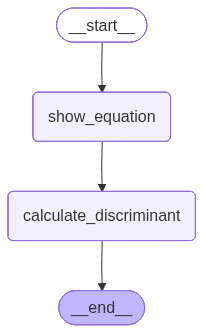

In [10]:
from IPython.display import Image

Image(
    workflow.get_graph().draw_mermaid_png()
)

In [15]:
initial_state = {
    'a': 4,
    'b': -5,
    'c': -6
}

final_state = workflow.invoke(initial_state)
print(final_state)

{'a': 4, 'b': -5, 'c': -6, 'equation': '4x2-5x-6', 'discriminant': 121}
